# **Ablation Study 2: Circuit Depth and Quantum Expressibility**

**NOTE:** Use T4 GPU Runtime on Google Colab

### **Objective**
In our previous experiments, we observed that while hybrid models can achieve high accuracy, they often get trapped in local minima or barren plateaus depending on their random weight initialization (Seed variance).

This experiment investigates **Quantum Expressibility** by scaling the `LAYERS` (depth) of the quantum circuit. A deeper circuit contains more trainable parameters and complex entanglement operations $\implies$ theoretically allows it to learn much more intricate representations of the data.

### **Hypothesis**
Increasing the circuit depth from 1 to 3 layers will grant the quantum model higher expressibility $\implies$ enables gradient descent to navigate around local minima. This should result in a higher average validation accuracy and a significantly tighter standard deviation across random seeds.

* **Fixed Parameters:** Entanglement = `ring`, Qubits = `4`, Epochs = `10`, Seeds = `[42, 100, 2026]`
* **Independent Variable:** Circuit Depth (Layers) `[1, 2, 3]`

In [1]:
import os
import sys
import torch
from google.colab import drive

# Mount Drive to access our saved weights
drive.mount('/content/drive')

# Clone repo or pull latest changes
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    os.chdir('/content/QML4EO-reproduction')
    !git pull
else:
    print("Cloning repo for the first time..")
    os.chdir('/content')
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    os.chdir('/content/QML4EO-reproduction')

if '/content/QML4EO-reproduction' not in sys.path:
    sys.path.append('/content/QML4EO-reproduction')

!pip install -r requirements.txt -q

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nHardware utilized: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Cloning repo for the first time..
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 166 (delta 67), reused 138 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 13.84 MiB | 19.64 MiB/s, done.
Resolving deltas: 100% (67/67), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

#### **Initialize Data Loaders**
We must use the exact same resolution ($224\times224$) that we used to fine-tune the classical model $\leftarrow$ so the spatial dimensions perfectly match the saved weights.

In [2]:
from src.utils.data_loader import get_eurosat_dataloaders

# Use the optimized loader parameters (num_workers=2, pin_memory=True)
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=64,
    img_size=224,
    num_workers=2,
    pin_memory=True
)

100%|██████████| 94.3M/94.3M [00:01<00:00, 64.0MB/s]


Dataset loaded successfully! Total: 27000 | Train: 21600 | Val: 5400


#### **The Circuit Depth Ablation Loop**
We evaluate quantum circuits of `1, 2 and 3 Layers`.

PennyLane uses the Parameter-Shift rule to calculate gradients $\implies$ adding layers increases the number of trainable quantum parameters $\implies$ which directly increases the simulation time per epoch.

We test across 3 distinct random initializations (`SEEDS = [42, 100, 2026]`) to strictly measure stability.

In [3]:
import numpy as np
from src.baselines.cnn import set_seed
from src.models.hqcnn import HybridQCNN, train_decoupled_hqcnn

# Path to the weights we generated in Notebook 2
WEIGHTS_PATH = '/content/drive/MyDrive/QML4EO-reproduction/models/finetuned_resnet18_eurosat.pth'

# Fixed Hyperparameters (Isolating the Depth variable)
ENTANGLEMENT = "ring"
QUBITS = 4
EPOCHS = 10
SEEDS = [42, 100, 2026]

# Ablation Variable
LAYERS_LIST = [1, 2, 3]

# Dictionary to store all statistical results
ablation_results = {}

print(f"\nStarting Ablation 2: Circuit Depth")

for layers in LAYERS_LIST:
    print(f"EXPERIMENT: {layers} LAYER(S)")

    all_train_losses = []
    all_val_accs = []

    for seed in SEEDS:
        print(f"\nTRAINING SEED: {seed}")
        print("-" * 30)

        set_seed(seed)

        # Initialize Hybrid Model
        model = HybridQCNN(
            num_classes=len(classes),
            num_qubits=QUBITS,
            num_layers=layers,
            entanglement_type=ENTANGLEMENT,
            pretrained_weights_path=WEIGHTS_PATH
        )

        # Run the Decoupled Training Loop
        history = train_decoupled_hqcnn(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            device=device
        )

        all_train_losses.append(history['train_loss'])
        all_val_accs.append(history['val_acc'])

    # Calculate statistics for this specific layer depth
    acc_array = np.array(all_val_accs)
    loss_array = np.array(all_train_losses)

    ablation_results[layers] = {
        'mean_acc': np.mean(acc_array, axis=0),
        'std_acc': np.std(acc_array, axis=0),
        'mean_loss': np.mean(loss_array, axis=0),
        'std_loss': np.std(loss_array, axis=0)
    }

    final_mean = ablation_results[layers]['mean_acc'][-1]
    final_std = ablation_results[layers]['std_acc'][-1]
    print(f"\n{layers}-Layer Phase Complete → Final Avg Acc: {final_mean:.2f}% ± {final_std:.2f}%")


Starting Ablation 2: Circuit Depth
EXPERIMENT: 1 LAYER(S)

TRAINING SEED: 42
------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]
Epoch 1/10 [Train]: 100%|██████████| 338/338 [01:01<00:00,  5.46it/s, loss=1.8963]


Epoch 1 Summary → Train Loss: 2.0508 | Val Accuracy: 60.96%


Epoch 2/10 [Train]: 100%|██████████| 338/338 [00:59<00:00,  5.72it/s, loss=1.4382]


Epoch 2 Summary → Train Loss: 1.6808 | Val Accuracy: 74.98%


...

Epoch 8 Summary → Train Loss: 0.7007 | Val Accuracy: 84.02%


Epoch 9/10 [Train]: 100%|██████████| 338/338 [01:01<00:00,  5.51it/s, loss=0.5443]


Epoch 9 Summary → Train Loss: 0.6430 | Val Accuracy: 88.67%


Epoch 10/10 [Train]: 100%|██████████| 338/338 [01:00<00:00,  5.57it/s, loss=0.6776]


Epoch 10 Summary → Train Loss: 0.5651 | Val Accuracy: 88.59%

3-Layer Phase Complete → Final Avg Acc: 87.17% ± 7.30%


#### **Visualization & Statistical Analysis**
The graphs below plot the mean performance across all seeds. Shaded regions represent $\pm \text{ Standard Deviation}$.

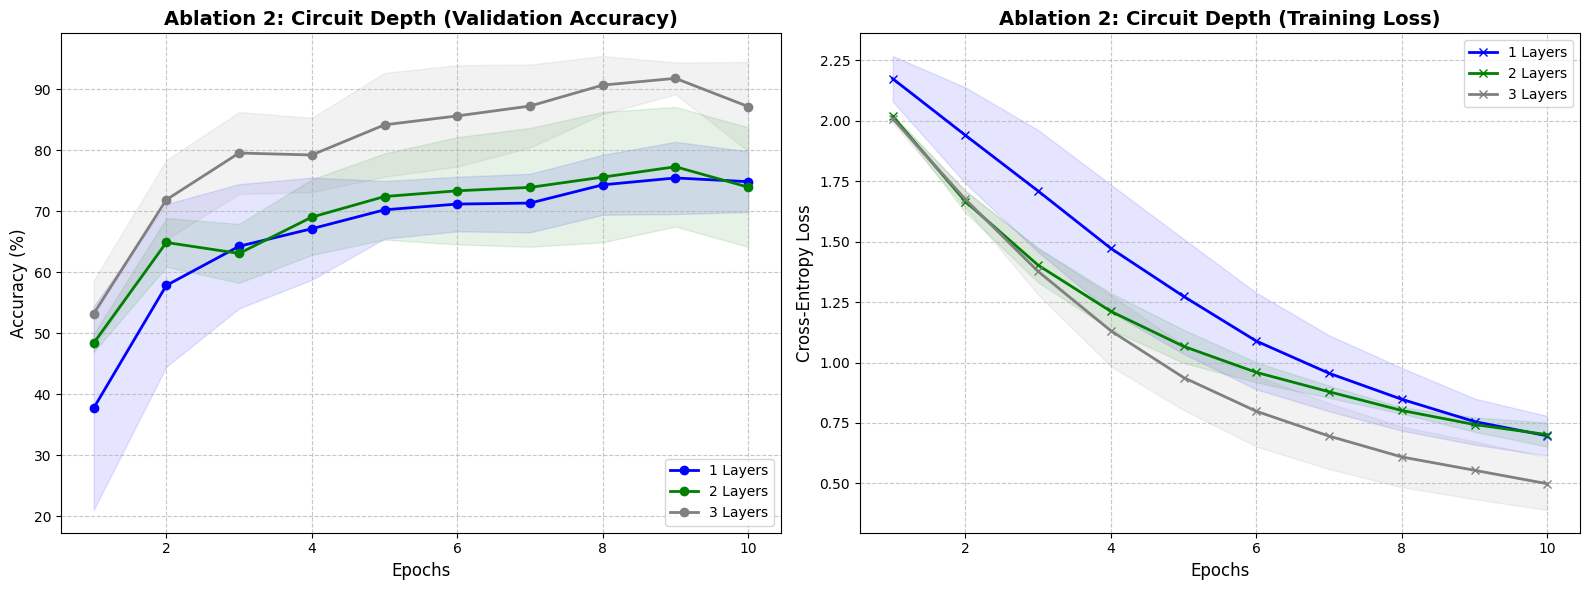

In [7]:
import matplotlib.pyplot as plt
epochs_range = range(1, EPOCHS + 1)
colors = {1: 'blue', 2: 'green', 3: 'grey'}

plt.figure(figsize=(16, 6))

# Plot 1: Validation Accuracy Comparison
plt.subplot(1, 2, 1)
for layers in LAYERS_LIST:
    mean_acc = ablation_results[layers]['mean_acc']
    std_acc = ablation_results[layers]['std_acc']

    plt.plot(epochs_range, mean_acc, label=f'{layers} Layers', color=colors[layers], marker='o', linewidth=2)
    plt.fill_between(epochs_range, mean_acc - std_acc, mean_acc + std_acc, color=colors[layers], alpha=0.1)

plt.title('Ablation 2: Circuit Depth (Validation Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Plot 2: Training Loss Comparison
plt.subplot(1, 2, 2)
for layers in LAYERS_LIST:
    mean_loss = ablation_results[layers]['mean_loss']
    std_loss = ablation_results[layers]['std_loss']

    plt.plot(epochs_range, mean_loss, label=f'{layers} Layers', color=colors[layers], marker='x', linewidth=2)
    plt.fill_between(epochs_range, mean_loss - std_loss, mean_loss + std_loss, color=colors[layers], alpha=0.1)

plt.title('Ablation 2: Circuit Depth (Training Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### **Empirical Observations: Expressibility v/s Barren Plateaus**

The results of the Circuit Depth ablation study challenge our initial hypothesis.

While we assumed that increasing depth would inherently increase stability by allowing gradient descent to navigate local minima; the data proves that **unmanaged quantum expressibility leads to severe optimization instability.**

* **1-Layer (Baseline):**
  * Maintained a stable average of 74.86% (± 4.97%)
* **2-Layer (Overparameterization):**
  * Average accuracy dropped to 73.96%, and the standard deviation doubled to ± 9.80%
  * This indicates the onset of **Barren Plateaus** $\rightarrow$ the deeper circuit flattened the loss landscape $\implies$ confused the optimizer and caused Seed 42 to flatline entirely in the low 60s.
* **3-Layer (High-Risk, High-Reward):**
  * This depth unlocked massive mathematical capacity $\leftarrow$ allowed Seed 100 to reach a 95.31% validation accuracy** with a beautifully smooth convergence curve
  * However, this depth is highly volatile; Seed 42 exhibited catastrophic forgetting, spiking to 93.22% at Epoch 8 before collapsing back to 77.61% by Epoch 10.

**Conclusion & Next Steps:**
* Deep quantum circuits possess the representational capacity to perfectly master the dataset (as seen with the 95.31% peak).
* However, without advanced training techniques, the gradients easily overshoot optimal minimums or get trapped in flat landscapes.
* To safely utilize deep quantum circuits $\rightarrow$ future work must incorporate quantum-specific learning rate decay or advanced parameter initialization strategies.

For our final architecture, the **1-Layer** model remains the most computationally efficient and stable choice for consistent baseline reproducibility.